In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# путь
input_path = "/content/episode_logs_ood_musique.jsonl"

episodes = []

with open(input_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        episodes.append(json.loads(line))

print("Загружено эпизодов:", len(episodes))
print("Пример эпизода:")
print(episodes[0])

Загружено эпизодов: 2417
Пример эпизода:
{'q_values': [1.013850450515747, 0.8912623524665833, 0.13625532388687134, 0.013853778131306171, -0.014413207769393921, -0.013692399486899376], 'actions': [17, 8, 9, 18, 6, 1], 'gt_ids': [17, 8], 'chunks': ['The Real L Word. The Real L Word is an American reality television series aired on the cable station Showtime, where it premiered on June 20, 2010. The show was created by executive producer Ilene Chaiken and Magical Elves Productions, following the success of the television drama "The L Word" also created by Chaiken. "The Real L Word" follows a group of lesbians in their daily lives in Los Angeles, and as of the third season, Brooklyn.', 'The Bourne Deception. The Bourne Deception is the title for the novel by Eric Van Lustbader and the seventh novel in the Jason Bourne series created by Robert Ludlum. It was released on June 9, 2009. It is Lustbader\'s fourth Bourne novel, following "The Bourne Sanction," which was published in 2008.', 'Tai

In [2]:
def get_earliest_step_with_all_gt(actions, gt_ids):
    gt = set(gt_ids)
    seen = set()
    for i, a in enumerate(actions):
        seen.add(a)
        if gt.issubset(seen):
            return i + 1
    return None

def get_stop_step(q_values, q_border):
    step = 0
    for q in q_values:
        if q < q_border:
            break
        step += 1
    return step

def classify_episode_time_based(ep, q_border):
    actions = ep["actions"]
    gt_ids = ep["gt_ids"]
    q_values = ep["q_values"]

    earliest_step = get_earliest_step_with_all_gt(actions, gt_ids)
    stop_step = get_stop_step(q_values, q_border)

    if earliest_step is None:
        return "not_found"  # агент сам по себе не способен собрать все gt

    if stop_step < earliest_step:
        return "early"
    elif stop_step == earliest_step:
        return "perfect"
    else:
        return "late"

In [3]:
def calc_fact_f1_em(predicted_support_idxs, gt_support_idxs):
    # Taken from hotpot_eval
    pred_sf = set(map(int, predicted_support_idxs))
    gt_sf = set(map(int, gt_support_idxs))
    tp, fp, fn = 0, 0, 0
    for e in pred_sf:
        if e in gt_sf:
            tp += 1
        else:
            fp += 1
    for e in gt_sf:
        if e not in pred_sf:
            fn += 1
    prec = 1.0 * tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = 1.0 * tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * prec * recall / (prec + recall) if prec + recall > 0 else 0.0
    em = 1.0 if gt_sf.issubset(pred_sf) else 0.0

    # In case everything is empty, set both f1, em to be 1.0.
    # Without this change, em gets 1 and f1 gets 0
    if not pred_sf and not gt_sf:
        f1, em = 1.0, 1.0
    return f1, em

In [4]:
# Симулируем выбор чанков при заданном q_border
def simulate_actions(episode, q_border):
    q_values = episode["q_values"]
    actions = episode["actions"]

    selected = []
    for q, a in zip(q_values, actions):
        # если q < порога, останавливаемся и не берём этот чанк
        if q < q_border:
            break
        selected.append(a)

    f1, em = calc_fact_f1_em(selected, episode["gt_ids"])

    return selected, f1, em

In [11]:
# сетка порогов: от -0.1 до 1.1 с шагом 0.1
q_borders = [round(-0.1 + 0.1 * i, 2) for i in range(13)]

early_rates = []
late_rates = []
fact_em_arr = []
fact_f1_arr = []
perfect_rates = []
avg_lengths = []  # среднее число выбранных чанков

for q_border in q_borders:
    early = late = perfect = not_found = 0
    lengths = []
    all_em = []
    all_f1 = []

    for ep in episodes:
        label = classify_episode_time_based(ep, q_border)
        selected, f1, em = simulate_actions(ep, q_border)
        all_em.append(em)
        all_f1.append(f1)
        lengths.append(len(selected))
        if label == "early":
            early += 1
        elif label == "late":
            late += 1
        elif label == "perfect":
            perfect += 1
        elif label == "not_found":
            not_found += 1

    n = len(episodes)
    correct_len = n - not_found
    early_rates.append(early / correct_len)
    late_rates.append(late / correct_len)
    perfect_rates.append(perfect / correct_len)
    avg_lengths.append(np.mean(lengths))
    fact_em = sum(all_em) / len(all_em)
    fact_em_arr.append(fact_em)
    fact_f1 = sum(all_f1) / len(all_f1)
    fact_f1_arr.append(fact_f1)

    print(
        f"q_border={q_border:.2f} | "
        f"early={early/correct_len:.3f}, late={late/correct_len:.3f}, perfect={perfect/correct_len:.3f}, "
        f"avg_len={np.mean(lengths):.2f}, "
        f'Coverage_score: {round(fact_em, 3)}, F1: {round(fact_f1, 3)}'
    )

q_border=-0.10 | early=0.000, late=0.913, perfect=0.087, avg_len=6.00, Coverage_score: 0.487, F1: 0.452
q_border=0.00 | early=0.075, late=0.665, perfect=0.260, avg_len=4.96, Coverage_score: 0.45, F1: 0.525
q_border=0.10 | early=0.241, late=0.257, perfect=0.503, avg_len=3.55, Coverage_score: 0.369, F1: 0.596
q_border=0.20 | early=0.340, late=0.136, perfect=0.524, avg_len=3.04, Coverage_score: 0.321, F1: 0.608
q_border=0.30 | early=0.391, late=0.065, perfect=0.543, avg_len=2.76, Coverage_score: 0.296, F1: 0.612
q_border=0.40 | early=0.458, late=0.037, perfect=0.505, avg_len=2.52, Coverage_score: 0.264, F1: 0.607
q_border=0.50 | early=0.503, late=0.016, perfect=0.480, avg_len=2.32, Coverage_score: 0.242, F1: 0.6
q_border=0.60 | early=0.537, late=0.006, perfect=0.457, avg_len=2.13, Coverage_score: 0.225, F1: 0.588
q_border=0.70 | early=0.554, late=0.002, perfect=0.445, avg_len=2.00, Coverage_score: 0.217, F1: 0.577
q_border=0.80 | early=0.612, late=0.001, perfect=0.387, avg_len=1.63, Cover

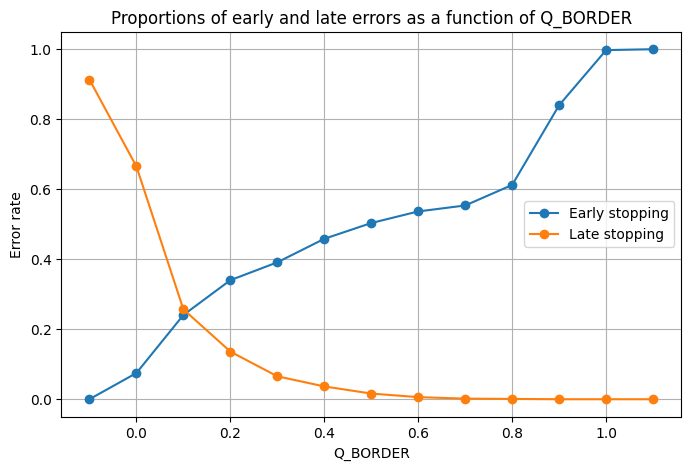

In [6]:
# График: error rate vs q_border
plt.figure(figsize=(8, 5))
plt.plot(q_borders, early_rates, marker="o", label="Early stopping")
plt.plot(q_borders, late_rates, marker="o", label="Late stopping")
plt.xlabel("Q_BORDER")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.title("Proportions of early and late errors as a function of Q_BORDER")
plt.show()

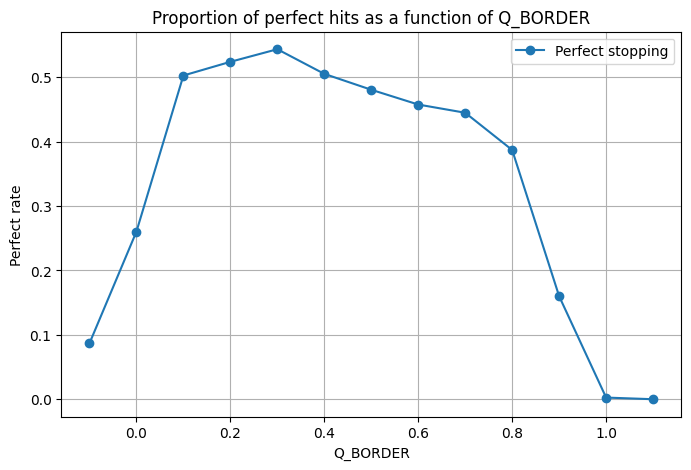

In [7]:
# График: perfect_rates vs q_border
plt.figure(figsize=(8, 5))
plt.plot(q_borders, perfect_rates, marker="o", label="Perfect stopping")
plt.xlabel("Q_BORDER")
plt.ylabel("Perfect rate")
plt.grid(True)
plt.legend()
plt.title("Proportion of perfect hits as a function of Q_BORDER")
plt.show()

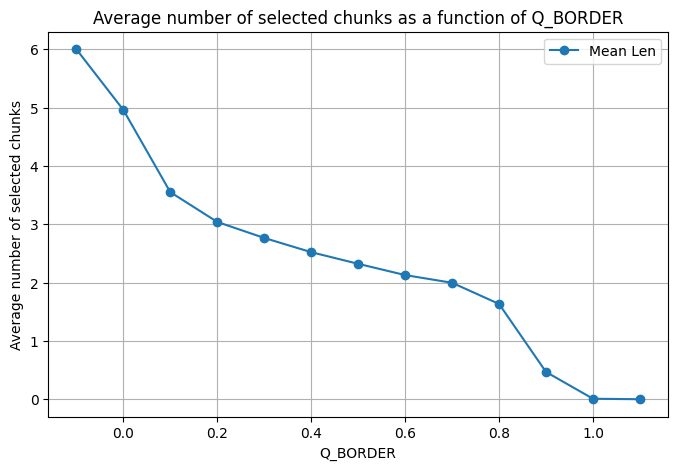

In [8]:
# График: avg_lengths vs q_border
plt.figure(figsize=(8, 5))
plt.plot(q_borders, avg_lengths, marker="o", label="Mean Len")
plt.xlabel("Q_BORDER")
plt.ylabel("Average number of selected chunks")
plt.grid(True)
plt.legend()
plt.title("Average number of selected chunks as a function of Q_BORDER")
plt.show()

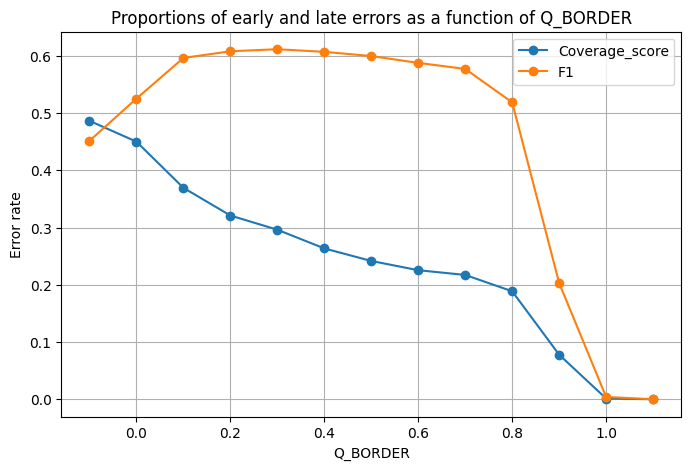

In [12]:
# График: error rate vs q_border
plt.figure(figsize=(8, 5))
plt.plot(q_borders, fact_em_arr, marker="o", label="Coverage_score")
plt.plot(q_borders, fact_f1_arr, marker="o", label="F1")
plt.xlabel("Q_BORDER")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.title("Proportions of early and late errors as a function of Q_BORDER")
plt.show()